# Árboles de decisión con características espectrales de dataicann

Ejemplo de clasificación interpretable del estado de un motor de inducción.

Se usan las mismas características que en `05_demo_clasificacion_svm_motor_induccion.py`, pero sustituyendo el modelo SVM por un árbol de decisión multiclase.

Correspondencia de variables en `dataicann`:

- `var1` = `a_c`
- `var2` = `a_x`
- `var3` = `a_y`
- `var4` = `i_R`
- `var5` = `i_S`

Clases que se van a predecir:

- `normal`
- `fallo_mecanico`
- `fallo_electrico`
- `fallo_electrico_y_mecanico`


## 1) Librerías e imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.io.matlab import loadmat
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

print("Python", sys.version.split()[0])
print("scikit-learn", sklearn.__version__)

Python 3.12.7
scikit-learn 1.8.0


## 2) Carga de datos

El fichero `dataicann.mat` contiene 9 ensayos. Las etiquetas originales del ejemplo son `[fallo_mecanico, fallo_electrico]`.

En este notebook combinamos ambas etiquetas binarias para obtener un problema de clasificación de 4 clases:

- `0`: normal
- `1`: fallo mecánico
- `2`: fallo eléctrico
- `3`: fallo eléctrico y mecánico simultáneos


In [2]:
def localizar_datos(nombre="dataicann.mat"):
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidato = base / "datos" / nombre
        if candidato.exists():
            return candidato
    raise FileNotFoundError(f"No se encuentra datos/{nombre} desde {Path.cwd()}")


ruta_datos = localizar_datos()
datos = loadmat(ruta_datos)
print(ruta_datos)

# Frecuencia de muestreo de dataicann.
fm = 5000.0

# Etiquetas de los 9 ensayos: [fallo_mecanico, fallo_electrico].
clase_ensayo = np.array(
    [
        [1.0, 0.0],
        [1.0, 1.0],
        [0.0, 0.0],
        [0.0, 1.0],
        [0.0, 1.0],
        [0.0, 1.0],
        [0.0, 1.0],
        [0.0, 1.0],
        [0.0, 1.0],
    ]
)

nombres_clases = [
    "normal",
    "fallo_mecanico",
    "fallo_electrico",
    "fallo_electrico_y_mecanico",
]

descripcion_ensayos = pd.DataFrame(
    clase_ensayo.astype(int),
    columns=["fallo_mecanico", "fallo_electrico"],
)
descripcion_ensayos["clase"] = [
    nombres_clases[mecanico + 2 * electrico]
    for mecanico, electrico in descripcion_ensayos[
        ["fallo_mecanico", "fallo_electrico"]
    ].to_numpy()
]
descripcion_ensayos.index = np.arange(1, len(descripcion_ensayos) + 1)
descripcion_ensayos


/Users/idiazblanco/Documents/Docencia/Mecatronica/Seminario Machine Learning 2024/ejemplos-curso-ML/datos/dataicann.mat


,fallo_mecanico,fallo_electrico,clase
1,1,0,fallo_mecanico
2,1,1,fallo_electrico_y_mecanico
3,0,0,normal
4,0,1,fallo_electrico
5,0,1,fallo_electrico
6,0,1,fallo_electrico
7,0,1,fallo_electrico
8,0,1,fallo_electrico
9,0,1,fallo_electrico


## 3) Extracción de características

Se replica el procedimiento del ejemplo SVM:

- ventana de `N = 1000` muestras
- salto de `S = 100` muestras
- bandas `20-30 Hz`, `95-105 Hz` y `45-55 Hz`
- señales usadas: `a_c`, `a_x` e `i_R`
- selección final de columnas equivalente a `F[:, [0, 1, 3, 4, 8]]`

La selección conserva dos bandas de `a_c`, dos bandas de `a_x` y una banda de `i_R`. El objetivo multiclase se calcula como:

```python
clase = fallo_mecanico + 2 * fallo_electrico
```


In [3]:
# Parámetros de enventanado: mismos valores que el ejemplo SVM.
N = 1000
S = 100

nombres_variables = {
    0: "a_c",  # var1
    1: "a_x",  # var2
    2: "a_y",  # var3
    3: "i_R",  # var4
    4: "i_S",  # var5
}

frecuencias = np.arange(0, fm, fm / N)
bandas = {
    "20_30Hz": np.where((frecuencias > 20) & (frecuencias < 30)),
    "95_105Hz": np.where((frecuencias > 95) & (frecuencias < 105)),
    "45_55Hz": np.where((frecuencias > 45) & (frecuencias < 55)),
}

variables = [0, 1, 3]
nombres_todas = [
    f"{nombres_variables[variable]}_{banda}"
    for variable in variables
    for banda in bandas
]

F = []
Fclase = []

for k in range(9):
    p = datos["z"][0][k].T
    Q = p.shape[1]

    for j in range(N, Q, S):
        caracteristicas = []

        for variable in variables:
            v = p[variable, j - N : j]
            V = np.abs(np.fft.fft(v))

            for idx in bandas.values():
                energia_banda = np.sqrt(np.sum(2 * V[idx] ** 2)) / N
                caracteristicas.append(energia_banda)

        F.append(caracteristicas)
        Fclase.append(clase_ensayo[k])

F = np.array(F)
Fclase = np.array(Fclase)

idx_caracteristicas = [0, 1, 3, 4, 8]
columnas_caracteristicas = [nombres_todas[i] for i in idx_caracteristicas]

X = pd.DataFrame(F[:, idx_caracteristicas], columns=columnas_caracteristicas)
y = (Fclase[:, 0] + 2 * Fclase[:, 1]).astype(int)

df = X.copy()
df["clase"] = y
df["diagnostico"] = [nombres_clases[i] for i in y]

print("Número total de ejemplos:", len(df))
print("Ejemplos por clase:")
print(df["diagnostico"].value_counts())
df.head()


Número total de ejemplos: 2012
Ejemplos por clase:
diagnostico
fallo_electrico               1442
fallo_mecanico                 190
fallo_electrico_y_mecanico     190
normal                         190
Name: count, dtype: int64


,a_c_20_30Hz,a_c_95_105Hz,a_x_20_30Hz,a_x_95_105Hz,i_R_45_55Hz,clase,diagnostico
0,0.025330,0.003492,0.043919,0.011783,0.526501,1,fallo_mecanico
1,0.026144,0.007408,0.043211,0.013383,0.526271,1,fallo_mecanico
2,0.025987,0.006887,0.043616,0.012527,0.526200,1,fallo_mecanico
3,0.026402,0.010088,0.043136,0.013235,0.526059,1,fallo_mecanico
4,0.025737,0.010035,0.043725,0.012431,0.526149,1,fallo_mecanico


## 4) Entrenar el árbol de decisión

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0,
)

clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    criterion="entropy",
    random_state=0,
)
clf.fit(X_train, y_train)

print("Árbol entrenado")
print("Profundidad:", clf.get_depth())
print("Número de hojas:", clf.get_n_leaves())
print("Precisión en entrenamiento:", clf.score(X_train, y_train))
print("Precisión en test:", clf.score(X_test, y_test))


Árbol entrenado
Profundidad: 2
Número de hojas: 4
Precisión en entrenamiento: 1.0
Precisión en test: 1.0


## 5) Reglas aprendidas

In [5]:
rules = export_text(clf, feature_names=columnas_caracteristicas)
print(rules)

|--- a_x_20_30Hz <= 0.03
|   |--- a_x_95_105Hz <= 0.01
|   |   |--- class: 0
|   |--- a_x_95_105Hz >  0.01
|   |   |--- class: 2
|--- a_x_20_30Hz >  0.03
|   |--- a_x_95_105Hz <= 0.15
|   |   |--- class: 1
|   |--- a_x_95_105Hz >  0.15
|   |   |--- class: 3



## 6) Evaluación

                            precision    recall  f1-score   support

                    normal       1.00      1.00      1.00        48
            fallo_mecanico       1.00      1.00      1.00        48
           fallo_electrico       1.00      1.00      1.00       360
fallo_electrico_y_mecanico       1.00      1.00      1.00        47

                  accuracy                           1.00       503
                 macro avg       1.00      1.00      1.00       503
              weighted avg       1.00      1.00      1.00       503



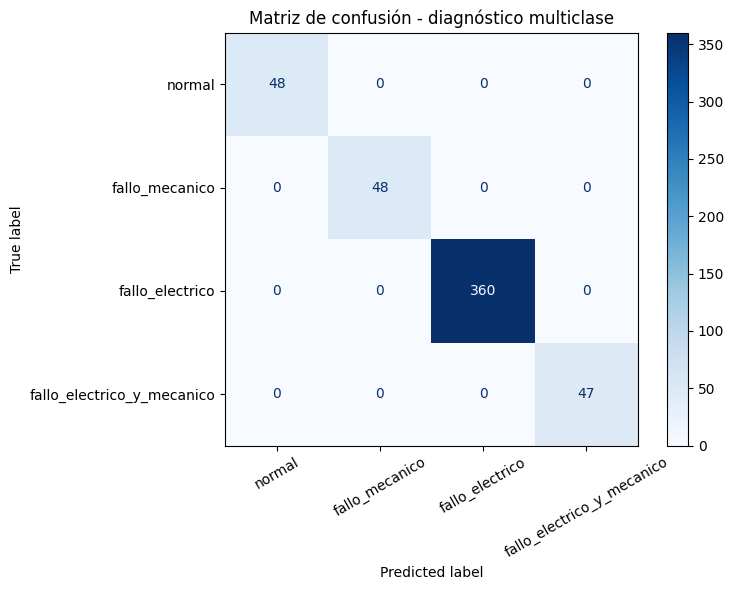

In [6]:
y_pred = clf.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        labels=np.arange(len(nombres_clases)),
        target_names=nombres_clases,
        zero_division=0,
    )
)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    labels=np.arange(len(nombres_clases)),
    display_labels=nombres_clases,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Matriz de confusión - diagnóstico multiclase")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()


## 7) Visualización del árbol

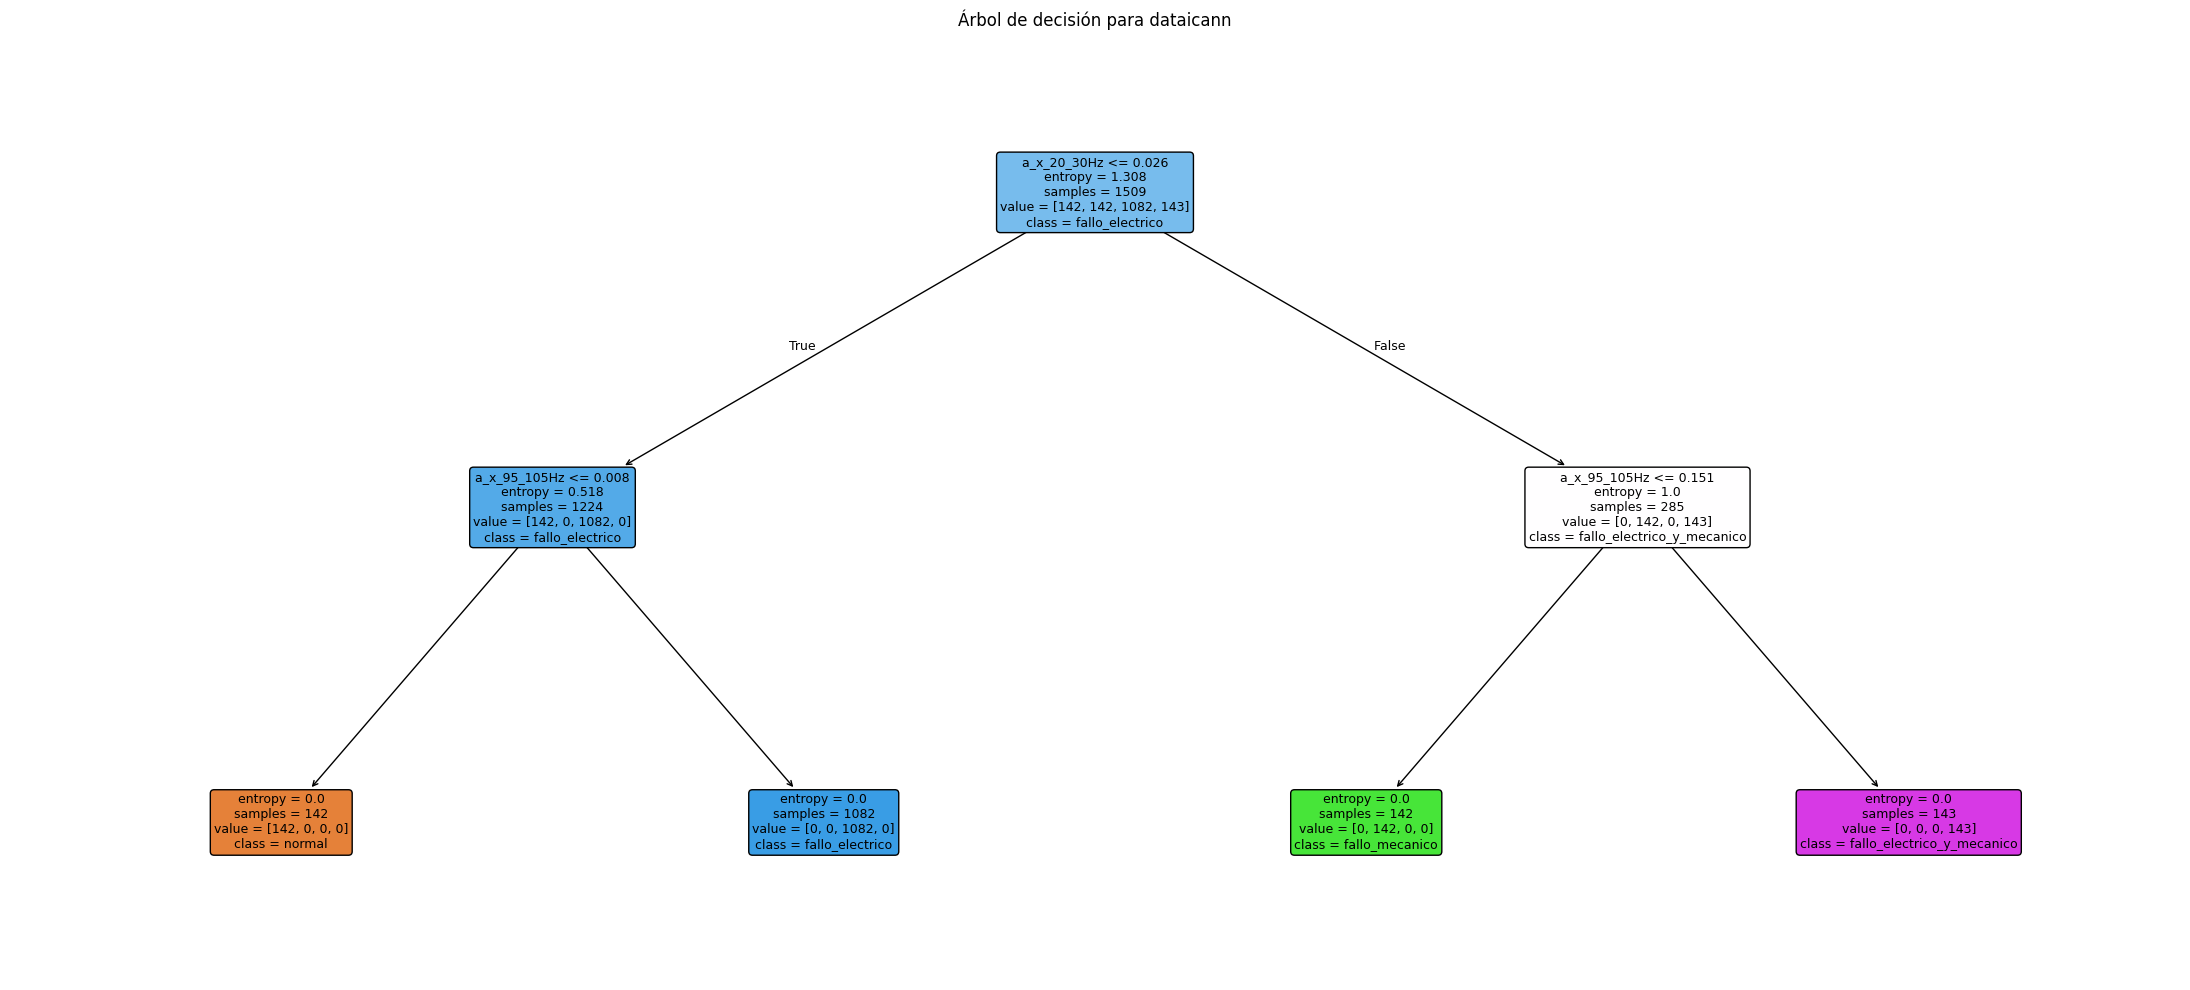

In [7]:
plt.figure(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=columnas_caracteristicas,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Árbol de decisión para dataicann")
plt.tight_layout()


## 8) Importancia de características


a_x_20_30Hz     0.534494
a_x_95_105Hz    0.465506
a_c_20_30Hz     0.000000
a_c_95_105Hz    0.000000
i_R_45_55Hz     0.000000
dtype: float64

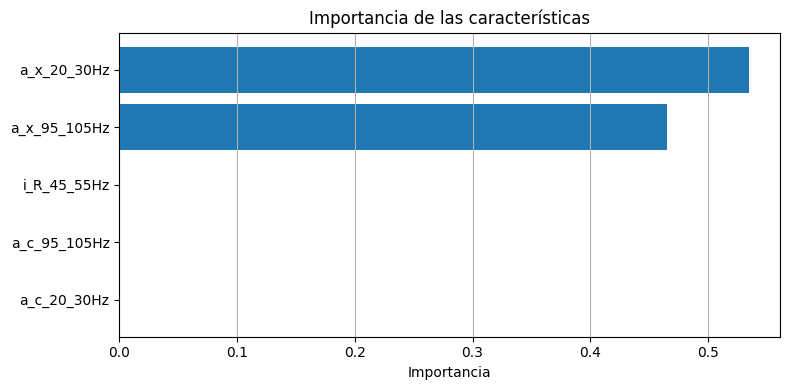

In [8]:
importancias = pd.Series(
    clf.feature_importances_,
    index=columnas_caracteristicas,
).sort_values()

plt.figure(figsize=(8, 4))
plt.barh(importancias.index, importancias.values)
plt.title("Importancia de las características")
plt.xlabel("Importancia")
plt.grid(True, axis="x")
plt.tight_layout()
importancias.sort_values(ascending=False)


## 9) Evolución de características y predicción


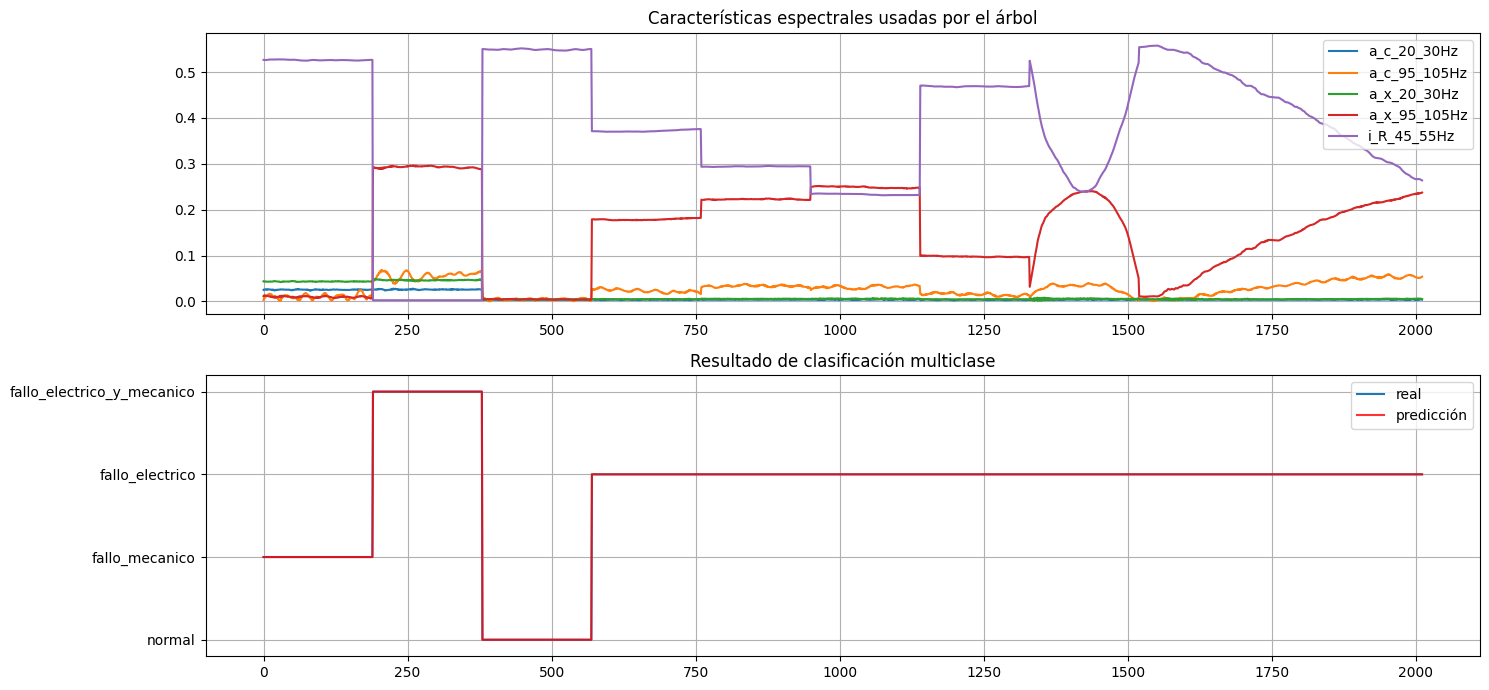

In [9]:
y_estimado = clf.predict(X)

plt.figure(figsize=(15, 7))

plt.subplot(2, 1, 1)
for columna in columnas_caracteristicas:
    plt.plot(X[columna].to_numpy(), label=columna)
plt.title("Características espectrales usadas por el árbol")
plt.grid(True)
plt.legend(loc="upper right")

plt.subplot(2, 1, 2)
plt.plot(y, label="real")
plt.plot(y_estimado, "r", alpha=0.8, label="predicción")
plt.yticks(np.arange(len(nombres_clases)), nombres_clases)
plt.ylim(-0.2, len(nombres_clases) - 0.8)
plt.title("Resultado de clasificación multiclase")
plt.grid(True)
plt.legend()

plt.tight_layout()
